In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
!nvidia-smi


GPU available: True
Fri Nov  7 05:25:08 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             12W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------------

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

train_dir = '/content/drive/MyDrive/medical_project/dataset/train'
val_dir   = '/content/drive/MyDrive/medical_project/dataset/val'
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)

print("Classes detected:")
print(train_dataset.classes)
print("Train:", len(train_dataset), "images")
print("Val:", len(val_dataset), "images")


Classes detected:
['BrainTumor-High', 'BrainTumor-Low', 'Cancer-Stage1', 'Cancer-Stage2', 'Cancer-Stage3', 'Cancer-Stage4', 'Pneumonia-Mild', 'Pneumonia-Moderate', 'Pneumonia-Severe', 'Tuberculosis-Active', 'Tuberculosis-Early', 'Tuberculosis-Latent']
Train: 2400 images
Val: 15 images


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

num_classes = len(train_dataset.classes)

class MedStageNet(nn.Module):
    def __init__(self, num_classes):
        super(MedStageNet, self).__init__()
        self.model = models.resnet18(pretrained=True)
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MedStageNet(num_classes).to(device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
def train_model(model, train_loader, val_loader, device, epochs=10):
    best_val_acc = 0.0
    for epoch in range(epochs):
        model.train()
        train_loss, correct = 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
            correct += torch.sum(preds == labels.data)
        train_acc = correct.double() / len(train_loader.dataset)


        model.eval()
        val_correct = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data)
        val_acc = val_correct.double() / len(val_loader.dataset)

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), '/content/drive/MyDrive/medical_project/best_model_resnet18.pth')
            print(" Best model saved!")

    print(f" Training complete! Best Validation Accuracy: {best_val_acc:.4f}")


In [ ]:
train_model(model=model, train_loader=train_loader, val_loader=val_loader, device=device,epochs=10)

Epoch 1/10 | Train Acc: 0.5100 | Val Acc: 0.4667
 Best model saved!
Epoch 2/10 | Train Acc: 0.5000 | Val Acc: 0.3333
Epoch 3/10 | Train Acc: 0.4992 | Val Acc: 0.4000
Epoch 4/10 | Train Acc: 0.5021 | Val Acc: 0.5333
 Best model saved!
Epoch 5/10 | Train Acc: 0.4783 | Val Acc: 0.4667
Epoch 6/10 | Train Acc: 0.5029 | Val Acc: 0.4000
Epoch 7/10 | Train Acc: 0.4958 | Val Acc: 0.4667
Epoch 8/10 | Train Acc: 0.4900 | Val Acc: 0.4667
Epoch 9/10 | Train Acc: 0.4996 | Val Acc: 0.4667
Epoch 10/10 | Train Acc: 0.4829 | Val Acc: 0.4667
 Training complete! Best Validation Accuracy: 0.5333


In [ ]:
model.load_state_dict(torch.load('/content/drive/MyDrive/medical_project/best_model_resnet18.pth'))
model.eval()
print(" Model ready for prediction.")


 Model ready for prediction.


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

def predict_image(model, image_path, class_names):
    img = Image.open(image_path).convert("RGB")
    tensor = val_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(tensor)
        probs = F.softmax(outputs, dim=1)
        conf, pred_idx = torch.max(probs, 1)
        pred_class = class_names[pred_idx.item()]

        if "-" in pred_class:
            disease, stage = pred_class.split("-", 1)
        else:
            disease, stage = pred_class, "Unknown Stage"

        print(f" Disease: {disease}")
        print(f" Stage / Severity: {stage}")
        print(f" Confidence: {conf.item()*100:.2f}%")

        plt.imshow(img)
        plt.title(f"{disease} ({stage}) — {conf.item()*100:.1f}%")
        plt.axis('off')
        plt.show()


 Disease: BrainTumor
 Stage / Severity: High
 Confidence: 100.00%


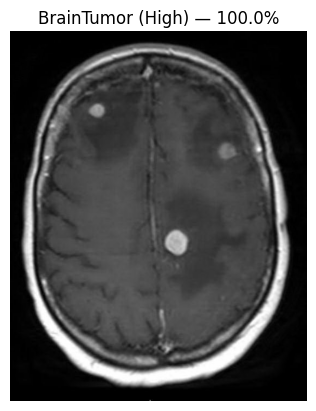

In [ ]:
image_path = '/content/drive/MyDrive/medical_project/dataset/val/BrainTumor-High/Tumor_High.jpg'
predict_image(model, image_path, train_dataset.classes)
